# Module 2: Probabilities, Persistence, and Mode Selection

**Workshop Track:** 100-Level | Introduction
**Prerequisites:** Module 1 complete, your `MODEL_ID` from Module 1

---

In Module 1 we trained our first credit risk classifier and got back hard binary predictions: `0` (no default) or `1` (default). That is a start, but it is not how credit decisions actually get made in practice.

A loan officer does not want to know which bucket a borrower lands in. They want to know *how risky* each borrower is, so they can rank them, set thresholds, and apply different interventions to different risk tiers. That is what Module 2 is about.

We also tackle two operational patterns you will use constantly: reloading a trained model without retraining, and choosing the right training mode for the task at hand.

Let's dig in.


## Learning Objectives

By the end of this notebook you will:

- Reload your Module 1 model with `clf.load_model(MODEL_ID)` — no retraining needed
- Use `predict_proba()` to generate continuous default probability scores
- Build a risk-ranked borrower list sorted by default probability
- Tune the decision threshold to control the precision/recall balance
- Visualize model performance with a ROC curve
- Train a `"speed"` mode model and compare it directly against `"quality"`

---

## Picking Up Where We Left Off

Before we do anything new, we need to re-establish the session: import libraries, connect to the client, and reload our data. The `MODEL_ID` you trained in Module 1 is retrieved automatically via `%store -r` — no manual copy-paste needed.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, confusion_matrix
)
from fundamental import Fundamental, NEXUSClassifier, set_client

# Retrieve stored variables from Module 1
%store -r FUNDAMENTAL_API_KEY
os.environ["FUNDAMENTAL_API_KEY"] = FUNDAMENTAL_API_KEY
print(f"API key loaded (prefix: {FUNDAMENTAL_API_KEY[:8]}...)")

# Authenticate
set_client(Fundamental())
print("Client configured.")

API key loaded (prefix: ak_17749...)
Client configured.


### Your Module 1 Model ID

The cell below retrieves the model ID you trained in Module 1 using IPython's `%store` mechanism. This was saved automatically at the end of Module 1.

If the retrieval fails (e.g., you cleared your IPython database or are running on a different machine), you can look up your models via the client:

```python
from fundamental import Fundamental
client = Fundamental()  # reads FUNDAMENTAL_API_KEY from env
for m in client.models.list()[:5]:
    print(m)
```

In [2]:
# Retrieve your Module 1 model ID (stored automatically if you ran Module 1)
%store -r MODEL_ID
print(f"Using model: {MODEL_ID}")

Using model: d239c47e-5295-4165-a450-1815a7e0a3f6


### Reload the Data

We are working with the same files and features from Module 1. We define them once here so the rest of the notebook stays clean.


In [3]:
# Same dataset and features as Module 1
train_df   = pd.read_csv("../../dataset/credit_risk/borrowers_train.csv")
holdout_df = pd.read_csv("../../dataset/credit_risk/borrowers_holdout.csv")

NUMERIC_FEATURES = [
    "age",
    "distance_from_branch_miles",
    "num_previous_lenders",
    "total_employment_years",
]
TARGET = "default_flag"

X_train   = train_df[NUMERIC_FEATURES]
y_train   = train_df[TARGET]
X_holdout = holdout_df[NUMERIC_FEATURES]
y_holdout = holdout_df[TARGET]

print(f"Training set:  {X_train.shape}")
print(f"Holdout set:   {X_holdout.shape}")


Training set:  (4591, 4)
Holdout set:   (1149, 4)


## Part 1: Model Persistence with `load_model()`

### Why This Matters

In Module 1, `fit()` and `predict()` ran in the same session. Production does not work that way: you train once, then serve predictions from a separate process, a different machine, or another team's codebase.

The model ID is the model. Create a fresh `NEXUSClassifier`, call `load_model(MODEL_ID)` with the ID from a previous training run, and the estimator is immediately ready for `predict()` and `predict_proba()` — no retraining, no data upload, in any session. The model weights stay in Fundamental's infrastructure and are invoked when you call `predict()`.

### How It Works

```
Your Code                       NEXUS Platform
─────────────────────────────────────────────────────────
clf.load_model(MODEL_ID)      → Estimator stores the ID
clf.predict(X)                 → Send ID + data to API
                               ← Return predictions
```

### When to Use This Pattern

| Scenario | Approach |
|----------|----------|
| New Jupyter session, same model | `clf.load_model(MODEL_ID)` |
| Prediction microservice on startup | `clf.load_model(os.environ["MODEL_ID"])` |
| A/B testing two model versions | Create two instances, load each with a different ID, compare predictions |
| Handing a model to another team | Share the model ID string |

Run the cell below. It should complete instantly — `load_model()` only registers the ID; predictions trigger the actual API call.

In [4]:
# Reuse the Module 1 model — no retraining, no data upload
nexus_quality = NEXUSClassifier()
nexus_quality.load_model(MODEL_ID)

print(f"Model set: {nexus_quality.trained_model_id_}")
print("\nReady for predictions.")

Model set: d239c47e-5295-4165-a450-1815a7e0a3f6

Ready for predictions.


**Already comfortable with probability scores?** Skip ahead to Part 3: Threshold Tuning.

## Part 2: From Binary Labels to Probability Scores

### The Problem with Hard Labels

In Module 1, `predict()` returned `[0, 0, 1, 0, 1, ...]` — hard binary labels. These are useful in some contexts, but in credit risk they throw away information.

Consider two borrowers the model is uncertain about:
- Borrower A has a `0.48` default probability — just below the conventional 0.5 cutoff, so a 0.5 decision rule would label it `0` (no default).
- Borrower B has a `0.12` default probability — confidently predicted as no default, also returns `0`.

Both get the same label. But Borrower A is much riskier than Borrower B, and a good credit decision process should treat them differently.

### Enter `predict_proba()`

`predict_proba()` returns the raw probability the model assigns to each class. Instead of `0` or `1`, you get a number between `0.0` and `1.0` for each class.

**Output shape:** `(n_samples, n_classes)` — one row per borrower, one column per class.

For binary classification (no default = class 0, default = class 1):
- Column `0` = P(no default)
- Column `1` = P(default) — the one we care about

The two columns are the per-class probabilities and typically sum to about 1.0. We extract column 1 as our **default probability score**.

Run the cell below and examine the output.


In [5]:
# Generate probability scores instead of hard labels
probas = nexus_quality.predict_proba(X_holdout)

print(f"Output shape: {probas.shape}  (rows=borrowers, cols=classes)")
print()

# Extract the default probability (column index 1)
default_prob = probas[:, 1]

print("Sample probability scores (first 10 borrowers):")
sample = pd.DataFrame({
    "P(no default)": probas[:10, 0].round(4),
    "P(default)":    probas[:10, 1].round(4),
    "actual":        y_holdout.values[:10]
})
print(sample.to_string(index=False))
print()
print(f"Score range:  [{default_prob.min():.4f}, {default_prob.max():.4f}]")
print(f"Mean score:   {default_prob.mean():.4f}")

Output shape: (1149, 2)  (rows=borrowers, cols=classes)

Sample probability scores (first 10 borrowers):
 P(no default)  P(default)  actual
        0.8104      0.1896       0
        0.7769      0.2231       0
        0.1378      0.8622       1
        0.9593      0.0407       0
        0.9684      0.0316       0
        0.3046      0.6954       1
        0.9094      0.0906       1
        0.8240      0.1760       0
        0.9136      0.0864       0
        0.9480      0.0520       0

Score range:  [0.0054, 0.9862]
Mean score:   0.2344


### Building a Risk-Ranked Borrower List

Now that we have continuous probability scores, we can do something far more useful than a binary prediction: rank every borrower in the holdout set by their estimated default risk.

This is the output format that a credit analyst or risk committee actually works with. The highest-probability borrowers get escalated for review, flagged for a manual underwriting decision, or declined outright. Lower-probability borrowers move through the standard approval pipeline.

The cell below builds this ranked list and attaches it to the borrower data so you can see the raw features alongside the model score.


In [6]:
# Attach probability scores to the holdout borrower data
risk_df = holdout_df.copy()
risk_df["default_probability"] = default_prob
risk_df["actual_default"]      = y_holdout.values

# Sort by default probability descending — highest risk first
risk_df_sorted = risk_df.sort_values("default_probability", ascending=False)

# Show the top 15 highest-risk borrowers
display_cols = NUMERIC_FEATURES + ["default_probability", "actual_default"]
print("Top 15 Highest-Risk Borrowers (ranked by model score):")
print(risk_df_sorted[display_cols].head(15).to_string(index=False))


Top 15 Highest-Risk Borrowers (ranked by model score):
 age  distance_from_branch_miles  num_previous_lenders  total_employment_years  default_probability  actual_default
  27                          24                     1                     1.0             0.986250               1
  56                           2                     9                     3.0             0.985337               0
  29                          20                     3                     4.0             0.983658               1
  20                           8                     1                     1.0             0.981272               0
  20                           7                     1                     1.0             0.978524               1
  20                           6                     1                     1.0             0.978523               1
  25                          24                     1                     1.1             0.976168               1
  26             

### What to Look for in the Output

Scan the top of the list and check the `actual_default` column. A well-performing model should have a meaningful concentration of actual defaulters (`1`) near the top of the risk ranking, even if the list is not perfectly sorted.

This kind of ranked output is more actionable than a binary classification. Instead of "approve or decline," you now have a continuum you can apply policy to — for example: automatically approve below 0.15, manual review between 0.15 and 0.40, and decline above 0.40.

In the next section, we explore exactly how to find the right cutoff for your use case.


## Part 3: Threshold Tuning

### Why 0.5 Is Probably Wrong

Turning a probability score into a yes/no decision means choosing a threshold. The conventional default is `0.5`: label default when P(default) >= 0.5. That 0.5 is a convention for binary classification, not a rule the SDK imposes — a fine starting point, but almost certainly not optimal for your use case.

The right threshold depends on **how much each type of error costs**:

| Error Type | What happened | Business cost |
|-----------|--------------|--------------|
| False Positive | Predicted default, actual no default | Lost loan revenue (we rejected a good borrower) |
| False Negative | Predicted no default, actual default | Loan losses (we approved a bad borrower) |

A bank with low loss tolerance should lower the threshold (catch more defaulters, accept more false alarms). A bank competing aggressively for loan volume might raise it (miss some defaulters to avoid rejecting good borrowers).

### Exploring the Tradeoff

The cell below sweeps through thresholds from 0.05 to 0.65 and records precision and recall for the default class at each point. This gives us a concrete view of how the model behaves at different operating points.

One more metric appears in the sweep: **F1**, the harmonic mean of precision and recall. It weighs the two equally — and equal weighting is exactly what credit risk does not have. A missed default usually costs far more than a false alarm, so treat the F1-optimal threshold as a starting point, not the answer.


In [7]:
# Sweep thresholds and record precision/recall for the default class
from sklearn.metrics import precision_score, recall_score

thresholds   = np.arange(0.05, 0.66, 0.05)
precisions   = []
recalls      = []
f1_scores    = []

for thresh in thresholds:
    y_pred_thresh = (default_prob >= thresh).astype(int)
    # Guard against zero-division when no positives are predicted
    p = precision_score(y_holdout, y_pred_thresh, zero_division=0)
    r = recall_score(y_holdout, y_pred_thresh, zero_division=0)
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    precisions.append(p)
    recalls.append(r)
    f1_scores.append(f)

results_df = pd.DataFrame({
    "threshold": thresholds.round(2),
    "precision": np.round(precisions, 4),
    "recall":    np.round(recalls, 4),
    "f1":        np.round(f1_scores, 4)
})

print("Precision / Recall by Threshold (Default class):")
print(results_df.to_string(index=False))
print()

# Highlight the threshold with best F1
best_row = results_df.loc[results_df["f1"].idxmax()]
print(f"Best F1 threshold: {best_row['threshold']:.2f}  "
      f"(precision={best_row['precision']:.4f}, recall={best_row['recall']:.4f})")


Precision / Recall by Threshold (Default class):
 threshold  precision  recall     f1
      0.05     0.2276  0.9682 0.3685
      0.10     0.2880  0.9136 0.4379
      0.15     0.3292  0.8364 0.4724
      0.20     0.3978  0.8045 0.5323
      0.25     0.4628  0.7636 0.5763
      0.30     0.4968  0.7000 0.5811
      0.35     0.5489  0.6636 0.6008
      0.40     0.5973  0.6000 0.5986
      0.45     0.6508  0.5591 0.6015
      0.50     0.6909  0.5182 0.5922
      0.55     0.7241  0.4773 0.5753
      0.60     0.7619  0.4364 0.5549
      0.65     0.7843  0.3636 0.4969

Best F1 threshold: 0.45  (precision=0.6508, recall=0.5591)


### Applying a Custom Threshold

Once you have identified your operating threshold, applying it is straightforward: you get the probability scores from `predict_proba()` and apply your own cutoff. The cell below demonstrates this with a threshold of `0.35` — more conservative than the default `0.50`, meaning we flag more borrowers as risky.

Change the `THRESHOLD` value and re-run to see how the metrics shift.

In [8]:
# Apply a custom threshold — adjust this to explore different operating points
THRESHOLD = 0.35

y_pred_custom = (default_prob >= THRESHOLD).astype(int)

print(f"Threshold: {THRESHOLD}")
print(f"Flagged as high-risk: {y_pred_custom.sum():,} ({y_pred_custom.mean():.1%} of holdout)")
print()
print(classification_report(
    y_holdout, y_pred_custom,
    target_names=["No Default", "Default"]
))
print(f"ROC AUC (unchanged by threshold): {roc_auc_score(y_holdout, default_prob):.4f}")


Threshold: 0.35
Flagged as high-risk: 266 (23.2% of holdout)

              precision    recall  f1-score   support

  No Default       0.92      0.87      0.89       929
     Default       0.55      0.66      0.60       220

    accuracy                           0.83      1149
   macro avg       0.73      0.77      0.75      1149
weighted avg       0.85      0.83      0.84      1149

ROC AUC (unchanged by threshold): 0.8420


## Visualizing the ROC Curve

The threshold sweep above gives us a table, but the ROC curve gives us the full picture in one chart. It plots the True Positive Rate (recall) against the False Positive Rate at every possible threshold, showing us the complete performance envelope of the model.

Key things to read from the curve:
- **Area Under the Curve (AUC):** Closer to 1.0 is better. A diagonal line (AUC = 0.5) is a random classifier.
- **The operating point:** The dot marks where our custom threshold sits on the curve.
- **The tradeoff region:** The steeper the curve rises before bending right, the better the model is at catching defaulters without generating too many false alarms.


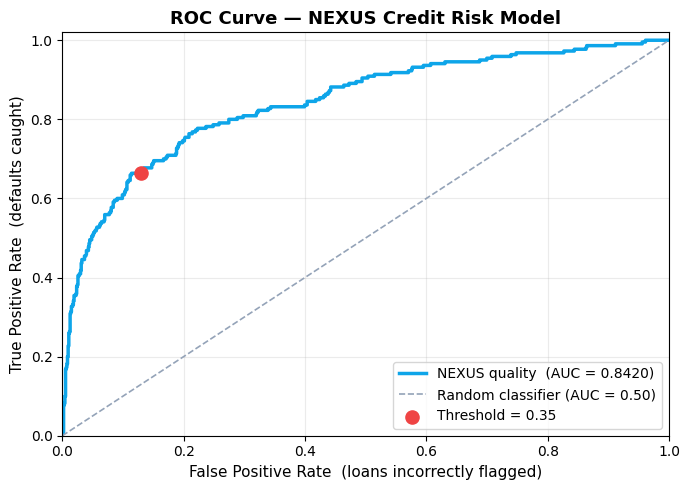

In [9]:
# Compute ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_holdout, default_prob)
auc_score = roc_auc_score(y_holdout, default_prob)

# Find the operating point for our custom threshold
op_idx = np.argmin(np.abs(roc_thresholds - THRESHOLD))

fig, ax = plt.subplots(figsize=(7, 5))

# ROC curve
ax.plot(fpr, tpr, color="#0EA5E9", lw=2.5,
        label=f"NEXUS quality  (AUC = {auc_score:.4f})")

# Random baseline
ax.plot([0, 1], [0, 1], color="#94A3B8", lw=1.2,
        linestyle="--", label="Random classifier (AUC = 0.50)")

# Operating point
ax.scatter(fpr[op_idx], tpr[op_idx],
           color="#EF4444", s=90, zorder=5,
           label=f"Threshold = {THRESHOLD}")

ax.set_xlabel("False Positive Rate  (loans incorrectly flagged)", fontsize=11)
ax.set_ylabel("True Positive Rate  (defaults caught)", fontsize=11)
ax.set_title("ROC Curve — NEXUS Credit Risk Model", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()


## Part 4: quality vs speed — A Side-by-Side Comparison

In Module 1 we used `mode="quality"` without much explanation. Now let's make the tradeoff concrete by training a `"speed"` model on the same data and comparing the two directly.

### What Changes Between Modes

| | `quality` | `speed` |
|---|---|---|
| Training time | Longer (several minutes) | Faster |
| Model exploration | More configurations searched | Leaner, faster training run |
| When to use | Final model, validate before production | Prototyping, rapid iteration, CI pipelines |

The difference between the modes is how much training time each spends. `quality` explores more configurations in search of a more thorough fit. `speed` trains faster on a leaner run. That is a real tradeoff in time, but it does not guarantee a winner on accuracy.

On any given dataset, either mode can come out ahead on AUC, and the gap can be small. On smaller datasets the ranking is especially noisy and can flip from run to run. So treat the comparison below as a measurement, not a foregone conclusion: read whichever numbers your run prints rather than assuming which mode is higher.

The practical rule is to measure both on your own data and your own metric. Use `speed` for fast iteration, and validate `quality` before you commit to production — but let the numbers, not the mode name, decide.

The cell below trains the speed model. Notice that `mode` is set on the constructor (`NEXUSClassifier(mode="speed")`), not passed to `fit()`. The mode is part of the estimator's identity and stays fixed for the life of that instance.

In [10]:
# Train a speed model on the same training data
# mode is on the constructor.
nexus_speed = NEXUSClassifier(mode="speed")

print("Training speed model...")
nexus_speed.fit(X_train, y_train)

print(f"\nSpeed model ID: {nexus_speed.trained_model_id_}")
print("Done. Compare training time to your Module 1 quality model run.")

Training speed model...



Speed model ID: 9eb9884e-46ca-4a51-bb3f-0ac81e00c0f3
Done. Compare training time to your Module 1 quality model run.


### Comparing the Two Models

Now we have both models trained on identical data. Let's score the holdout set with each and compare the results directly.

We are looking for two things:
1. **ROC AUC difference** — which mode scores higher on this data, and by how much. The difference can go either way, and on a dataset this size it may be small.
2. **ROC curve shape** — where on the precision/recall tradeoff each model behaves differently.

Model Comparison — Holdout Set
Metric                       quality      speed
--------------------------------------------------
ROC AUC                       0.8420     0.8576
Precision (thresh=0.30)       0.4968     0.4433
Recall    (thresh=0.30)       0.7000     0.7636
F1        (thresh=0.30)       0.5811     0.5609


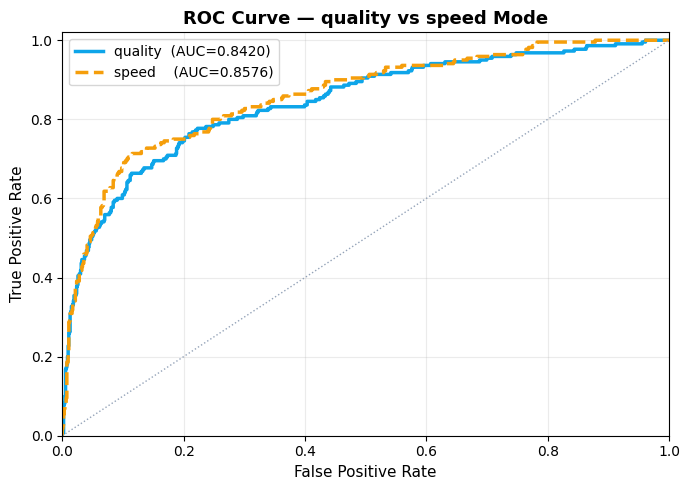

In [11]:
# Score the holdout set with the speed model
probas_speed = nexus_speed.predict_proba(X_holdout)
default_prob_speed = probas_speed[:, 1]

# Compute ROC for both models
fpr_q, tpr_q, _ = roc_curve(y_holdout, default_prob)
fpr_s, tpr_s, _ = roc_curve(y_holdout, default_prob_speed)
auc_q = roc_auc_score(y_holdout, default_prob)
auc_s = roc_auc_score(y_holdout, default_prob_speed)

# Side-by-side metric comparison
print("=" * 50)
print("Model Comparison — Holdout Set")
print("=" * 50)
print(f"{'Metric':<25} {'quality':>10} {'speed':>10}")
print("-" * 50)
print(f"{'ROC AUC':<25} {auc_q:>10.4f} {auc_s:>10.4f}")

# Metrics at threshold 0.30 for both
pred_q_30 = (default_prob       >= 0.30).astype(int)
pred_s_30 = (default_prob_speed >= 0.30).astype(int)

from sklearn.metrics import f1_score
for metric_name, fn in [("Precision (thresh=0.30)", precision_score),
                         ("Recall    (thresh=0.30)", recall_score),
                         ("F1        (thresh=0.30)", f1_score)]:
    vq = fn(y_holdout, pred_q_30, zero_division=0)
    vs = fn(y_holdout, pred_s_30, zero_division=0)
    print(f"{metric_name:<25} {vq:>10.4f} {vs:>10.4f}")

# Overlay ROC curves
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_q, tpr_q, color="#0EA5E9", lw=2.5, label=f"quality  (AUC={auc_q:.4f})")
ax.plot(fpr_s, tpr_s, color="#F59E0B", lw=2.5, linestyle="--",
        label=f"speed    (AUC={auc_s:.4f})")
ax.plot([0, 1], [0, 1], color="#94A3B8", lw=1, linestyle=":")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curve — quality vs speed Mode", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

### Saving the Speed Model ID

The speed model we just trained is a legitimate trained model stored in Fundamental's registry. Save the ID for reference, so you can reload either model later and compare them on your own metric.

In [12]:
SPEED_MODEL_ID = nexus_speed.trained_model_id_
%store SPEED_MODEL_ID
print(f"Speed model ID: {SPEED_MODEL_ID}")
print(f"Quality model ID: {MODEL_ID}")

Stored 'SPEED_MODEL_ID' (str)
Speed model ID: 9eb9884e-46ca-4a51-bb3f-0ac81e00c0f3
Quality model ID: d239c47e-5295-4165-a450-1815a7e0a3f6


## Key Takeaways

Here is what we covered in Module 2:

1. **`load_model()` decouples training from serving** — you never need to retrain to run predictions. Create a new `NEXUSClassifier` instance, call `load_model(MODEL_ID)`, and you are immediately ready to predict. This is how production systems work.

2. **`predict_proba()` is more useful than `predict()` for credit decisions** — continuous scores let you rank borrowers, set tier-specific policies, and tune the decision boundary to match your risk appetite.

3. **The 0.5 threshold is arbitrary** — sweeping thresholds and plotting the ROC curve shows you the full range of tradeoffs. The right operating point depends on how your organization weighs false positives against false negatives.

4. **`quality` vs `speed` is a tradeoff in training time, not a guaranteed accuracy ranking** — `quality` spends more time exploring a more thorough fit, `speed` trains faster. Either can score higher on AUC for a given dataset, and the gap can be small, especially on smaller data. Use `speed` for prototyping and rapid iteration, and validate `quality` before production — but measure both on your own data and your own metric rather than assuming which one wins.

5. **ROC AUC is your model quality scoreboard** — it is threshold-independent, so you can use it to compare models cleanly. This number goes on the wall in Module 3 when we add categorical features and watch it move.

---

## What's Next: Module 3

In Module 3 we unlock the full feature set:

- Adding categorical columns (`gender`, `marital_status`, `education_level`, `occupation_sector`) — NEXUS takes them as-is, and we add cleaning and joins that lift accuracy
- Parsing the date column `account_open_date` into a numeric tenure feature
- Handling the messy real-world version of the dataset (inconsistent casing, mixed types)
- Joining additional data sources: `financial_snapshots.csv`, `credit_assessments.csv`, and more
- Watching the ROC AUC improve when the model has more signal to work with

Your `MODEL_ID` and `SPEED_MODEL_ID` are passed automatically to the next notebook via `%store`.